# Darknet Traffic Detection Project


In [2]:
# Import required libraries
import pandas as pd
import numpy as np

## Phase 1 — Dataset Acquisition

In [3]:
# Load the dataset from Excel
# Make sure Darknet.xlsx is in the same folder as this notebook
df = pd.read_excel("Darknet.xlsx")

# Remove empty columns if any exist
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))


Dataset shape: (141531, 85)
Number of columns: 85


In [4]:
# View first rows
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,10.152.152.11-74.125.136.120-49134-443-6,10.152.152.11,49134,74.125.136.120,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0,0.000000e+00,0,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,10.152.152.11-173.194.65.127-34697-19305-6,10.152.152.11,34697,173.194.65.127,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1437764990528710,3.117718e+06,1437764995910100,1.437765e+15,Non-Tor,AUDIO-STREAMING


In [5]:
# Check dataset information (column types, null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141531 entries, 0 to 141530
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     141531 non-null  object 
 1   Src IP                      141531 non-null  object 
 2   Src Port                    141531 non-null  int64  
 3   Dst IP                      141531 non-null  object 
 4   Dst Port                    141531 non-null  int64  
 5   Protocol                    141531 non-null  int64  
 6   Timestamp                   141531 non-null  object 
 7   Flow Duration               141531 non-null  int64  
 8   Total Fwd Packet            141531 non-null  int64  
 9   Total Bwd packets           141531 non-null  int64  
 10  Total Length of Fwd Packet  141531 non-null  int64  
 11  Total Length of Bwd Packet  141531 non-null  int64  
 12  Fwd Packet Length Max       141531 non-null  int64  
 13  Fwd Packet Len

## Phase 2 — Data Preprocessing

In [6]:

# Some columns were loaded as 'object' (text) but should be numbers.
# pd.to_numeric will convert them, and any bad values become NaN.
# ------------------------------------------------------------------
mixed_type_cols = [
    'Fwd Header Length',
    'Bwd Header Length',
    'Bwd Packets/s',
    'Packet Length Mean'
]

for col in mixed_type_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Mixed-type columns converted to numeric.")

Mixed-type columns converted to numeric.


In [7]:
# Replace infinite values with NaN, then drop all rows with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print('Dataset shape after cleaning NaN/Inf rows:', df.shape)

Dataset shape after cleaning NaN/Inf rows: (141481, 85)


In [8]:
# Remove socket-related columns AND Timestamp
# These are identifiers, not useful features for ML
columns_to_remove = [
    'Flow ID',
    'Src IP',
    'Dst IP',
    'Src Port',
    'Dst Port',
    'Timestamp'     
]

df.drop(columns=columns_to_remove, inplace=True, errors='ignore')

print('Dataset shape after removing socket/timestamp columns:', df.shape)
print('Remaining columns:', df.shape[1])

Dataset shape after removing socket/timestamp columns: (141481, 79)
Remaining columns: 79


## Phase 3 — Label Engineering

The dataset has two label columns:
- `Label`   → contains: Tor, Non-Tor, VPN, NonVPN  (this is for Case 2)
- `Label.1` → contains: traffic types like P2P, Browsing, etc.

**Case 1 (Binary):** We need to create a Benign vs Darknet label.
- "Non-Tor" maps to → **Benign**
- "Tor", "VPN", "NonVPN" map to → **Darknet**

**Case 2 (Multiclass):** Tor / Non-Tor / VPN / Non-VPN
- We use the `Label` column directly, but fix naming inconsistencies.

In [9]:

# Some rows have numeric values like '5494.505495' in the Label column
# These are invalid — keep only known valid labels
# ------------------------------------------------------------------
valid_labels = ['Non-Tor', 'Tor', 'VPN', 'NonVPN']
df = df[df['Label'].isin(valid_labels)]

print("Rows after removing corrupted label rows:", len(df))
print("\nLabel column unique values:", df['Label'].unique())

Rows after removing corrupted label rows: 141481

Label column unique values: ['Non-Tor' 'NonVPN' 'Tor' 'VPN']


In [10]:
# ------------------------------------------------------------------
# CASE 1: Binary Classification — Benign vs Darknet
# Map: Non-Tor → Benign | Tor, VPN, NonVPN → Darknet
# ------------------------------------------------------------------
label_map_binary = {
    'Non-Tor': 'Benign',
    'Tor':     'Darknet',
    'VPN':     'Darknet',
    'NonVPN':  'Darknet'
}

df['Label_Binary'] = df['Label'].map(label_map_binary)

print("Case 1 — Binary label distribution:")
print(df['Label_Binary'].value_counts())

Case 1 — Binary label distribution:
Label_Binary
Benign     93309
Darknet    48172
Name: count, dtype: int64


In [11]:
# ------------------------------------------------------------------
# CASE 2: Multiclass Classification — Tor / Non-Tor / VPN / Non-VPN
# The Label column already has these values, but 'NonVPN' should be
# standardised to 'Non-VPN' to match the paper
# ------------------------------------------------------------------
label_map_multi = {
    'Non-Tor': 'Non-Tor',
    'Tor':     'Tor',
    'VPN':     'VPN',
    'NonVPN':  'Non-VPN'   # standardise naming
}

df['Label_Multi'] = df['Label'].map(label_map_multi)

print("Case 2 — Multiclass label distribution:")
print(df['Label_Multi'].value_counts())

Case 2 — Multiclass label distribution:
Label_Multi
Non-Tor    93309
Non-VPN    23861
VPN        22919
Tor         1392
Name: count, dtype: int64


In [12]:
# ------------------------------------------------------------------
# Prepare X (features) and y (labels) for both cases
# Drop all label columns from features
# ------------------------------------------------------------------
label_cols = ['Label', 'Label.1', 'Label_Binary', 'Label_Multi']

X = df.drop(columns=label_cols, errors='ignore')
y_binary = df['Label_Binary']   # Case 1
y_multi  = df['Label_Multi']    # Case 2

print("Feature matrix shape (X):", X.shape)
print("Binary labels shape   (y_binary):", y_binary.shape)
print("Multi  labels shape   (y_multi):", y_multi.shape)

Feature matrix shape (X): (141481, 77)
Binary labels shape   (y_binary): (141481,)
Multi  labels shape   (y_multi): (141481,)


In [13]:
# Final sanity check — make sure X has only numeric columns
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("WARNING: These columns are still non-numeric and will cause problems:", non_numeric)
else:
    print("All feature columns are numeric. Ready for Phase 4 (Train/Test Split)!")

print("\nFinal feature count:", X.shape[1])
print("Final row count:", X.shape[0])

All feature columns are numeric. Ready for Phase 4 (Train/Test Split)!

Final feature count: 77
Final row count: 141481


## Phase 4 — Train / Test Split

In [14]:

from sklearn.model_selection import train_test_split, StratifiedKFold

# ── Case 1: Binary (Benign vs Darknet) ──────────────────────────────
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary,
    test_size=0.2,        # 20% goes to test
    random_state=42,      # makes results reproducible
    stratify=y_binary     # keeps class balance (important!)
)

# ── Case 2: Multiclass (Tor / Non-Tor / VPN / Non-VPN) ──────────────
X_train_mul, X_test_mul, y_train_mul, y_test_mul = train_test_split(
    X, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

# ── 5-Fold Cross-Validation setup (used later during training) ───────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Confirm shapes ────────────────────────────────────────────────────
print("=== Case 1 — Binary ===")
print(f"  Train: {X_train_bin.shape}  |  Test: {X_test_bin.shape}")
print(f"  Train labels:\n{y_train_bin.value_counts()}")
print(f"\n  Test labels:\n{y_test_bin.value_counts()}")

print("\n=== Case 2 — Multiclass ===")
print(f"  Train: {X_train_mul.shape}  |  Test: {X_test_mul.shape}")
print(f"  Train labels:\n{y_train_mul.value_counts()}")

=== Case 1 — Binary ===
  Train: (113184, 77)  |  Test: (28297, 77)
  Train labels:
Label_Binary
Benign     74647
Darknet    38537
Name: count, dtype: int64

  Test labels:
Label_Binary
Benign     18662
Darknet     9635
Name: count, dtype: int64

=== Case 2 — Multiclass ===
  Train: (113184, 77)  |  Test: (28297, 77)
  Train labels:
Label_Multi
Non-Tor    74647
Non-VPN    19089
VPN        18335
Tor         1113
Name: count, dtype: int64


## Phase 5 — Train ML Models

In [21]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_models():
    """Always returns FRESH, unfitted model instances."""
    return {
        'kNN':           KNeighborsClassifier(n_neighbors=8),
        'MLP':           MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
        'Random Forest': RandomForestClassifier(max_depth=16, n_estimators=50, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Grad. Boost':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    }

# ── Scale features for MLP
scaler  = StandardScaler()
scaler2 = StandardScaler()
X_train_bin_scaled = scaler.fit_transform(X_train_bin)
X_test_bin_scaled  = scaler.transform(X_test_bin)
X_train_mul_scaled = scaler2.fit_transform(X_train_mul)
X_test_mul_scaled  = scaler2.transform(X_test_mul)

def train_models(X_train, y_train,
                 X_train_scaled, case_name):
    print(f"\n{'='*50}")
    print(f"  {case_name}")
    print(f"{'='*50}")
    trained = {}
    for name, model in make_models().items():        # fresh models every time!
        start = time.time()
        X_tr = X_train_scaled if name == 'MLP' else X_train
        cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
        model.fit(X_tr, y_train)
        elapsed = time.time() - start
        trained[name] = model
        print(f"  {name:<20} CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  ({elapsed:.1f}s)")
    return trained

print("Training started — this may take a few minutes...")

trained_bin = train_models(X_train_bin, y_train_bin,
                            X_train_bin_scaled,
                            "Case 1 — Binary (Benign vs Darknet)")

trained_mul = train_models(X_train_mul, y_train_mul,
                            X_train_mul_scaled,
                            "Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)")

print("\nAll models trained successfully!")

Training started — this may take a few minutes...

  Case 1 — Binary (Benign vs Darknet)
  kNN                  CV Accuracy: 0.9679 ± 0.0008  (7.7s)
  MLP                  CV Accuracy: 0.9943 ± 0.0007  (950.6s)
  Random Forest        CV Accuracy: 0.9982 ± 0.0003  (58.3s)
  Decision Tree        CV Accuracy: 0.9980 ± 0.0003  (16.8s)
  Grad. Boost          CV Accuracy: 0.9966 ± 0.0002  (556.9s)

  Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)
  kNN                  CV Accuracy: 0.9515 ± 0.0013  (16.4s)
  MLP                  CV Accuracy: 0.9593 ± 0.0014  (1316.7s)
  Random Forest        CV Accuracy: 0.9833 ± 0.0005  (36.4s)
  Decision Tree        CV Accuracy: 0.9793 ± 0.0009  (7.7s)
  Grad. Boost          CV Accuracy: 0.9769 ± 0.0006  (1161.6s)

All models trained successfully!


## Phase 6 — Evaluation Metrics


  Case 1 — Binary (Benign vs Darknet)
  Model                 Accuracy  Precision   Recall   F-score
  ----------------------------------------------------------
  kNN                    0.9688     0.9693   0.9688    0.9686
  MLP                    0.9950     0.9950   0.9950    0.9950
  Random Forest          0.9981     0.9981   0.9981    0.9981
  Decision Tree          0.9980     0.9980   0.9980    0.9980
  Grad. Boost            0.9961     0.9961   0.9961    0.9961

  Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)
  Model                 Accuracy  Precision   Recall   F-score
  ----------------------------------------------------------
  kNN                    0.9529     0.9515   0.9529    0.9499
  MLP                    0.9592     0.9596   0.9592    0.9592
  Random Forest          0.9843     0.9843   0.9843    0.9842
  Decision Tree          0.9799     0.9798   0.9799    0.9798
  Grad. Boost            0.9773     0.9774   0.9773    0.9774


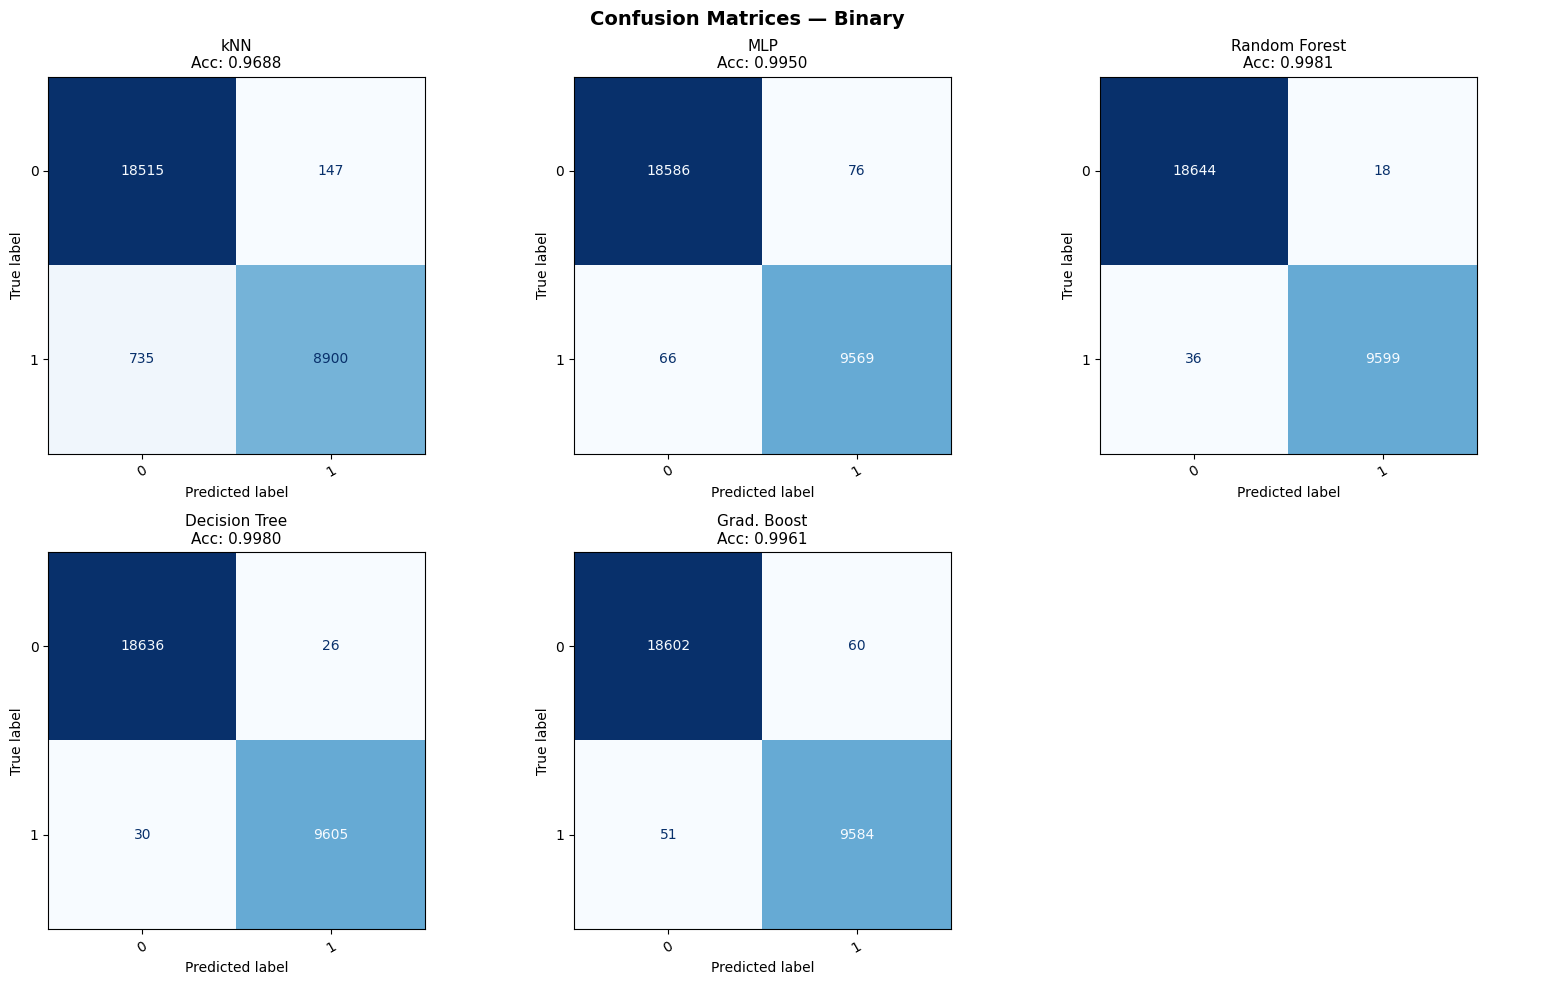

Saved: confusion_matrices_binary.png


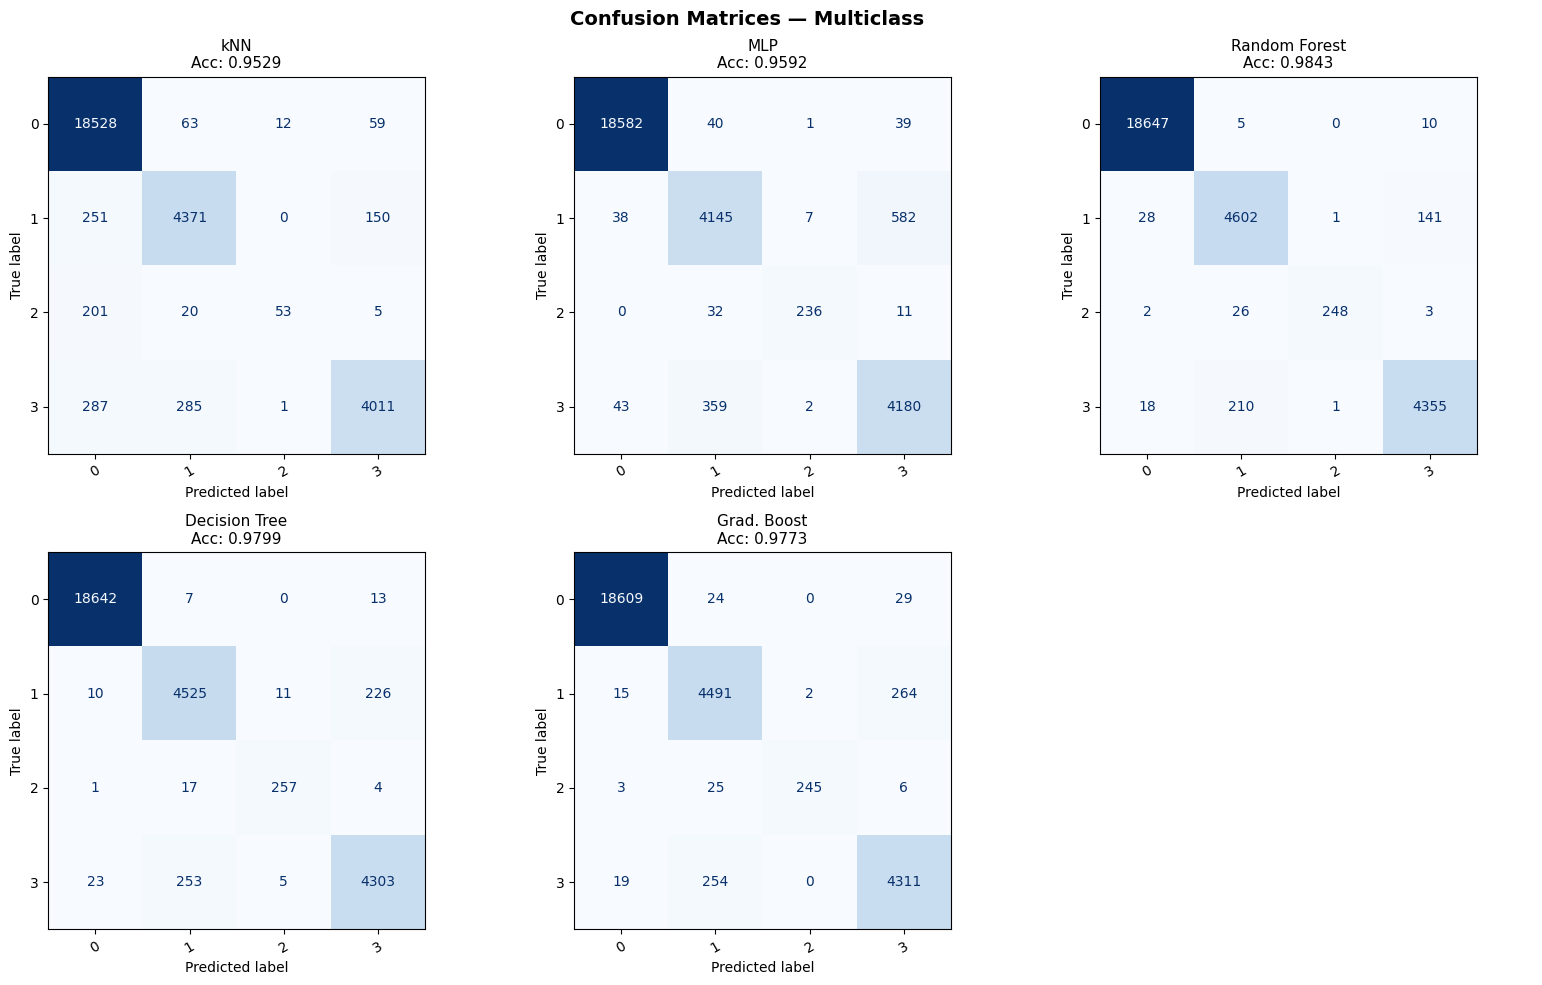

Saved: confusion_matrices_multi.png

Phase 6 complete!


In [22]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def evaluate_models(trained, case_num, X_test, y_test, case_name):
    print(f"\n{'='*65}")
    print(f"  {case_name}")
    print(f"{'='*65}")
    print(f"  {'Model':<20} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F-score':>9}")
    print(f"  {'-'*58}")

    results = {}
    for name, model in trained.items():
        X_eval = (X_test_bin_scaled if case_num == 1 else X_test_mul_scaled) \
                 if name == 'MLP' else X_test

        y_pred = model.predict(X_eval)
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        results[name] = {'accuracy': acc, 'precision': prec,
                         'recall': rec,  'f1': f1, 'y_pred': y_pred}
        print(f"  {name:<20} {acc:>8.4f}  {prec:>9.4f}  {rec:>7.4f}  {f1:>8.4f}")

    return results

results_bin = evaluate_models(trained_bin, 1, X_test_bin, y_test_bin,
                               "Case 1 — Binary (Benign vs Darknet)")
results_mul = evaluate_models(trained_mul, 2, X_test_mul, y_test_mul,
                               "Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)")

# ── Confusion Matrices
def plot_confusion_matrices(trained, results, y_test, case_name):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    fig.suptitle(f'Confusion Matrices — {case_name}', fontsize=14, fontweight='bold')

    for i, (name, _) in enumerate(trained.items()):
        y_pred = results[name]['y_pred']
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(f'{name}\nAcc: {results[name]["accuracy"]:.4f}', fontsize=11)
        axes[i].tick_params(axis='x', rotation=30)

    axes[5].axis('off')
    plt.tight_layout()
    fname = 'confusion_matrices_binary.png' if 'Binary' in case_name else 'confusion_matrices_multi.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

plot_confusion_matrices(trained_bin, results_bin, y_test_bin, "Binary")
plot_confusion_matrices(trained_mul, results_mul, y_test_mul, "Multiclass")

print("\nPhase 6 complete!")

##  PHASE 7 — ROC Analysis (Random Forest — Best Classifier)

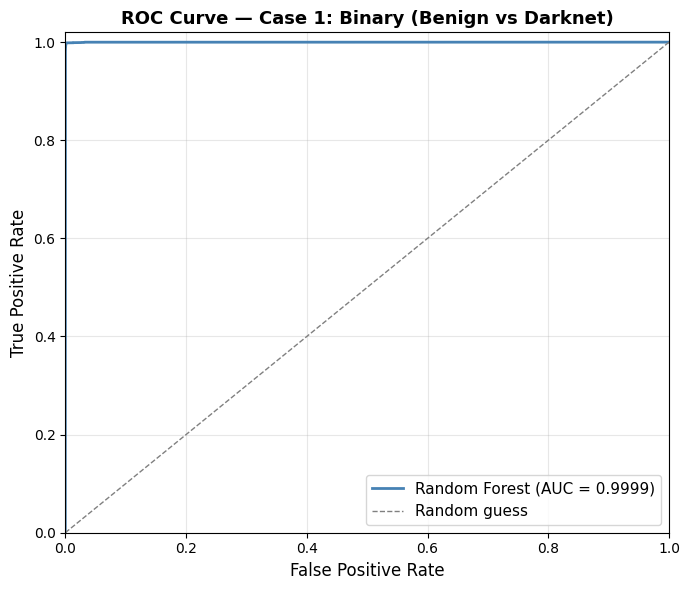

Case 1 AUC: 0.9999  |  Saved: roc_case1_binary.png


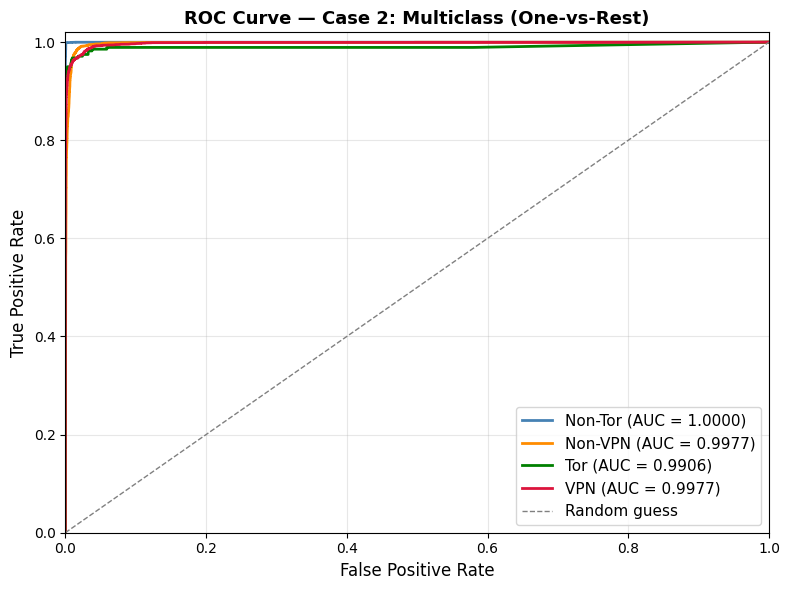

Case 2 AUC per class:
  Non-Tor    AUC = 1.0000
  Non-VPN    AUC = 0.9977
  Tor        AUC = 0.9906
  VPN        AUC = 0.9977
Saved: roc_case2_multiclass.png

Phase 7 complete!


In [23]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

rf_bin = trained_bin['Random Forest']
rf_mul = trained_mul['Random Forest']

# CASE 1: Binary ROC 
fig, ax = plt.subplots(figsize=(7, 6))

y_score_bin = rf_bin.predict_proba(X_test_bin)[:, 1]

# Map labels to 0/1 for roc_curve
y_test_bin_num = (y_test_bin == 'Darknet').astype(int)

fpr, tpr, _ = roc_curve(y_test_bin_num, y_score_bin)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Random Forest (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Case 1: Binary (Benign vs Darknet)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_case1_binary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Case 1 AUC: {roc_auc:.4f}  |  Saved: roc_case1_binary.png")

# CASE 2: Multiclass ROC (One-vs-Rest) 
classes = ['Non-Tor', 'Non-VPN', 'Tor', 'VPN']
colors  = ['steelblue', 'darkorange', 'green', 'crimson']

# Binarize labels for One-vs-Rest
y_test_bin2 = label_binarize(y_test_mul, classes=classes)
y_score_mul = rf_mul.predict_proba(X_test_mul)

# Make sure column order matches 'classes'
class_order = list(rf_mul.classes_)
col_idx = [class_order.index(c) for c in classes]
y_score_mul = y_score_mul[:, col_idx]

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin2[:, i], y_score_mul[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, color=color, lw=2,
            label=f'{cls} (AUC = {auc_i:.4f})')

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Case 2: Multiclass (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_case2_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
print("Case 2 AUC per class:")
for i, cls in enumerate(classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin2[:, i], y_score_mul[:, i])
    print(f"  {cls:<10} AUC = {auc(fpr_i, tpr_i):.4f}")
print("Saved: roc_case2_multiclass.png")

print("\nPhase 7 complete!")

## PHASE 8 — Feature Importance (Random Forest)

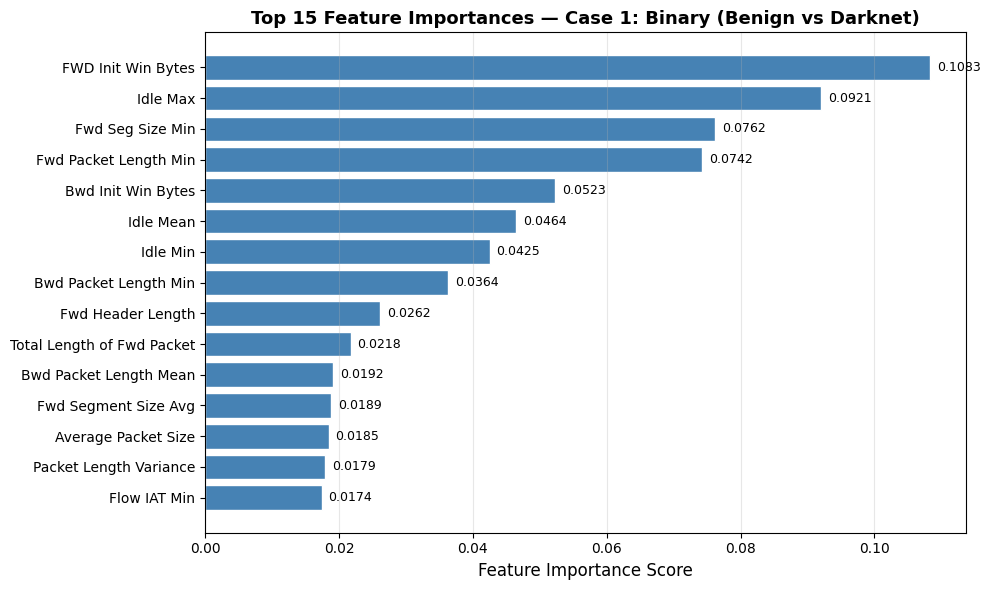

Saved: feature_importance_case1.png

Top 15 features for Case 1: Binary (Benign vs Darknet):
   1. FWD Init Win Bytes                  0.1083
   2. Idle Max                            0.0921
   3. Fwd Seg Size Min                    0.0762
   4. Fwd Packet Length Min               0.0742
   5. Bwd Init Win Bytes                  0.0523
   6. Idle Mean                           0.0464
   7. Idle Min                            0.0425
   8. Bwd Packet Length Min               0.0364
   9. Fwd Header Length                   0.0262
  10. Total Length of Fwd Packet          0.0218
  11. Bwd Packet Length Mean              0.0192
  12. Fwd Segment Size Avg                0.0189
  13. Average Packet Size                 0.0185
  14. Packet Length Variance              0.0179
  15. Flow IAT Min                        0.0174


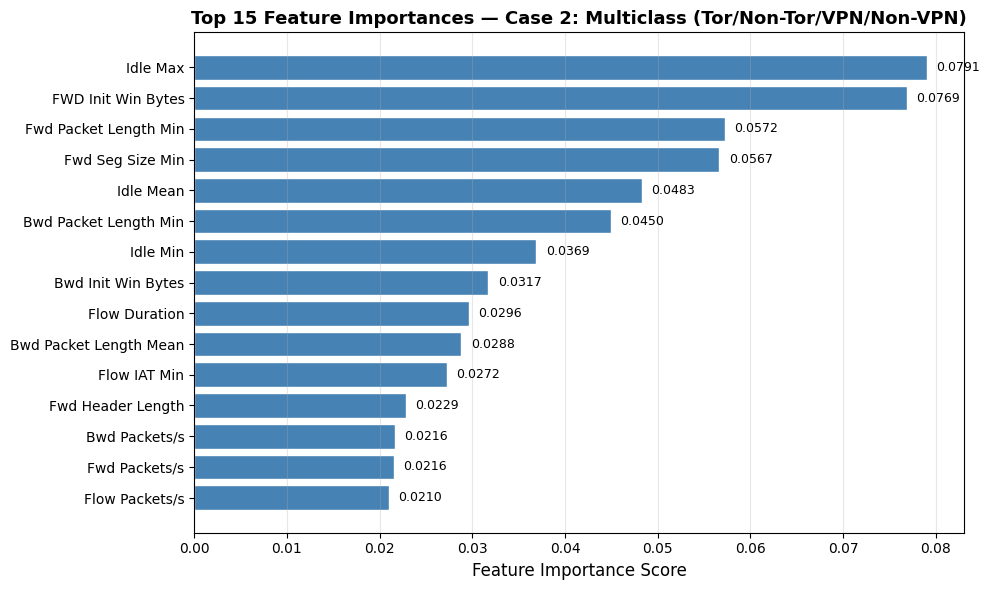

Saved: feature_importance_case2.png

Top 15 features for Case 2: Multiclass (Tor/Non-Tor/VPN/Non-VPN):
   1. Idle Max                            0.0791
   2. FWD Init Win Bytes                  0.0769
   3. Fwd Packet Length Min               0.0572
   4. Fwd Seg Size Min                    0.0567
   5. Idle Mean                           0.0483
   6. Bwd Packet Length Min               0.0450
   7. Idle Min                            0.0369
   8. Bwd Init Win Bytes                  0.0317
   9. Flow Duration                       0.0296
  10. Bwd Packet Length Mean              0.0288
  11. Flow IAT Min                        0.0272
  12. Fwd Header Length                   0.0229
  13. Bwd Packets/s                       0.0216
  14. Fwd Packets/s                       0.0216
  15. Flow Packets/s                      0.0210

  Top 5 Feature Comparison
  Rank   Case 1                              Case 2
  -----------------------------------------------------
  1      FWD Init Win Byte

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rf_bin = trained_bin['Random Forest']
rf_mul = trained_mul['Random Forest']

feature_names = X_train_bin.columns.tolist()

def plot_feature_importance(model, feature_names, case_name, filename, top_n=15):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]

    top_features = [feature_names[i] for i in indices]
    top_values   = importances[indices]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_features[::-1], top_values[::-1],
                   color='steelblue', edgecolor='white')

    # Add value labels on bars
    for bar, val in zip(bars, top_values[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlabel('Feature Importance Score', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importances — {case_name}',
                 fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

    # Print ranked list
    print(f"\nTop {top_n} features for {case_name}:")
    for rank, (feat, val) in enumerate(zip(top_features, top_values), 1):
        print(f"  {rank:>2}. {feat:<35} {val:.4f}")

    return top_features, top_values

#  Case 1: Binary
top_feat_bin, top_val_bin = plot_feature_importance(
    rf_bin, feature_names,
    "Case 1: Binary (Benign vs Darknet)",
    "feature_importance_case1.png"
)

#  Case 2: Multiclass
top_feat_mul, top_val_mul = plot_feature_importance(
    rf_mul, feature_names,
    "Case 2: Multiclass (Tor/Non-Tor/VPN/Non-VPN)",
    "feature_importance_case2.png"
)

# Side-by-side comparison of top 5
print("\n" + "="*55)
print("  Top 5 Feature Comparison")
print("="*55)
print(f"  {'Rank':<6} {'Case 1':<35} {'Case 2'}")
print(f"  {'-'*53}")
for i in range(5):
    print(f"  {i+1:<6} {top_feat_bin[i]:<35} {top_feat_mul[i]}")

print("\nPhase 8 complete!")

## Compare and Report Results


  Case 1 — Binary (Benign vs Darknet)
               Accuracy  Precision  Recall  F-score
Model                                              
kNN              0.9688     0.9693  0.9688   0.9686
MLP              0.9950     0.9950  0.9950   0.9950
Random Forest    0.9981     0.9981  0.9981   0.9981
Decision Tree    0.9980     0.9980  0.9980   0.9980
Grad. Boost      0.9961     0.9961  0.9961   0.9961

  Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)
               Accuracy  Precision  Recall  F-score
Model                                              
kNN              0.9529     0.9515  0.9529   0.9499
MLP              0.9592     0.9596  0.9592   0.9592
Random Forest    0.9843     0.9843  0.9843   0.9842
Decision Tree    0.9799     0.9798  0.9799   0.9798
Grad. Boost      0.9773     0.9774  0.9773   0.9774


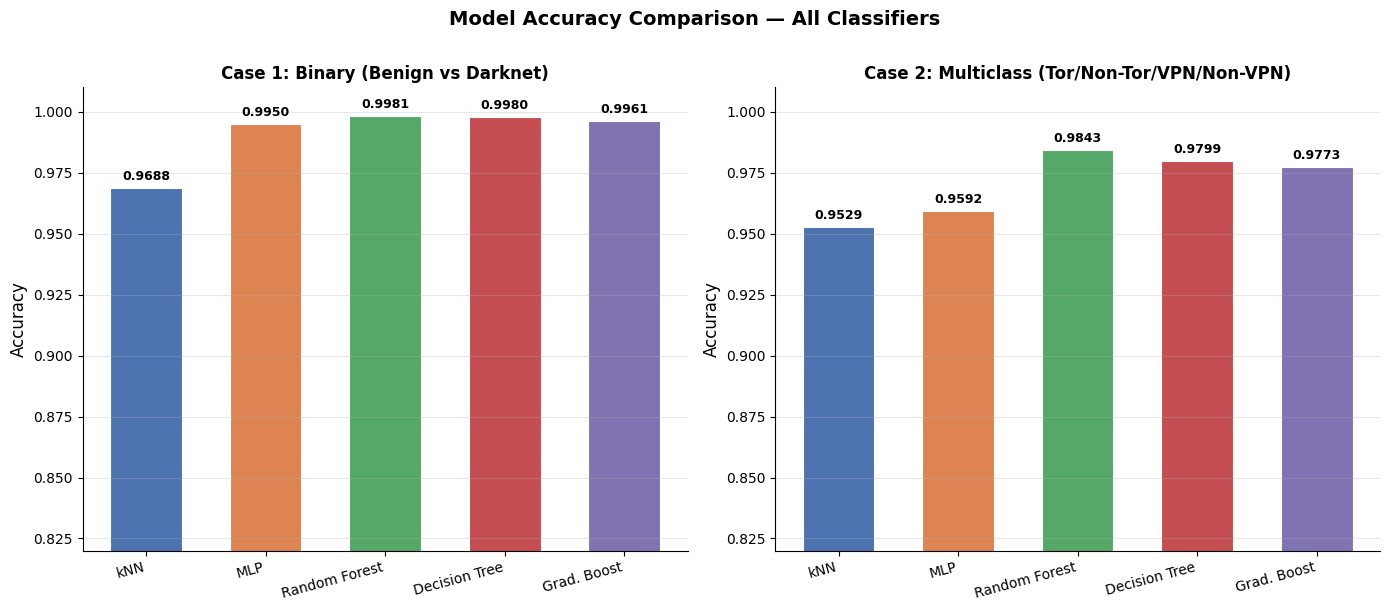

Saved: phase9_accuracy_comparison.png

  FINAL SUMMARY
  Case 1 Best Model : Random Forest
    Accuracy  : 0.9981
    Precision : 0.9981
    Recall    : 0.9981
    F-score   : 0.9981

  Case 2 Best Model : Random Forest
    Accuracy  : 0.9843
    Precision : 0.9843
    Recall    : 0.9843
    F-score   : 0.9842

  ROC AUC (Random Forest):
    Case 1 (Binary)     : 0.9999
    Case 2 Non-Tor      : 1.0000
    Case 2 Non-VPN      : 0.9977
    Case 2 VPN          : 0.9977
    Case 2 Tor          : 0.9906

  Top Feature (Case 1)  : FWD Init Win Bytes  (0.1083)
  Top Feature (Case 2)  : Idle Max            (0.0791)

Phase 9 complete! 


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Build summary DataFrames from Phase 6 results 
def build_summary(results, case_name):
    rows = []
    for name, metrics in results.items():
        rows.append({
            'Model':     name,
            'Accuracy':  round(metrics['accuracy'],  4),
            'Precision': round(metrics['precision'], 4),
            'Recall':    round(metrics['recall'],    4),
            'F-score':   round(metrics['f1'],        4),
        })
    df = pd.DataFrame(rows).set_index('Model')
    print(f"\n{'='*60}")
    print(f"  {case_name}")
    print(f"{'='*60}")
    print(df.to_string())
    return df

df_bin = build_summary(results_bin, "Case 1 — Binary (Benign vs Darknet)")
df_mul = build_summary(results_mul, "Case 2 — Multiclass (Tor/Non-Tor/VPN/Non-VPN)")

#  Bar chart: Accuracy comparison 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
models = list(results_bin.keys())
x = np.arange(len(models))
width = 0.6

for ax, df, title in zip(axes,
                          [df_bin, df_mul],
                          ["Case 1: Binary (Benign vs Darknet)",
                           "Case 2: Multiclass (Tor/Non-Tor/VPN/Non-VPN)"]):
    bars = ax.bar(x, df['Accuracy'], width=width,
                  color=colors, edgecolor='white', linewidth=0.8)

    # Value labels on top of bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(df.index, rotation=15, ha='right', fontsize=10)
    ax.set_ylim([0.82, 1.01])
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Model Accuracy Comparison — All Classifiers',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phase9_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase9_accuracy_comparison.png")

#  Best model summary 
best_bin = df_bin['Accuracy'].idxmax()
best_mul = df_mul['Accuracy'].idxmax()

print(f"""
{'='*60}
  FINAL SUMMARY
{'='*60}
  Case 1 Best Model : {best_bin}
    Accuracy  : {df_bin.loc[best_bin, 'Accuracy']:.4f}
    Precision : {df_bin.loc[best_bin, 'Precision']:.4f}
    Recall    : {df_bin.loc[best_bin, 'Recall']:.4f}
    F-score   : {df_bin.loc[best_bin, 'F-score']:.4f}

  Case 2 Best Model : {best_mul}
    Accuracy  : {df_mul.loc[best_mul, 'Accuracy']:.4f}
    Precision : {df_mul.loc[best_mul, 'Precision']:.4f}
    Recall    : {df_mul.loc[best_mul, 'Recall']:.4f}
    F-score   : {df_mul.loc[best_mul, 'F-score']:.4f}

  ROC AUC (Random Forest):
    Case 1 (Binary)     : 0.9999
    Case 2 Non-Tor      : 1.0000
    Case 2 Non-VPN      : 0.9977
    Case 2 VPN          : 0.9977
    Case 2 Tor          : 0.9906

  Top Feature (Case 1)  : FWD Init Win Bytes  (0.1083)
  Top Feature (Case 2)  : Idle Max            (0.0791)
{'='*60}
""")

print("Phase 9 complete! ")